Using device: cuda

===== Running: No regularization | weight_decay=0.0 =====
Epoch [01/50] | Train Loss: 1.6335 | Train Acc: 0.4113 | Val Loss: 1.3252 | Val Acc: 0.5228
Epoch [02/50] | Train Loss: 1.1723 | Train Acc: 0.5804 | Val Loss: 1.1821 | Val Acc: 0.5872
Epoch [03/50] | Train Loss: 0.9980 | Train Acc: 0.6449 | Val Loss: 1.0785 | Val Acc: 0.6182
Epoch [04/50] | Train Loss: 0.9044 | Train Acc: 0.6801 | Val Loss: 1.0773 | Val Acc: 0.6116
Epoch [05/50] | Train Loss: 0.8324 | Train Acc: 0.7094 | Val Loss: 1.0282 | Val Acc: 0.6466
Epoch [06/50] | Train Loss: 0.7842 | Train Acc: 0.7220 | Val Loss: 1.1073 | Val Acc: 0.6202
Epoch [07/50] | Train Loss: 0.7479 | Train Acc: 0.7361 | Val Loss: 0.9686 | Val Acc: 0.6688
Epoch [08/50] | Train Loss: 0.7097 | Train Acc: 0.7525 | Val Loss: 1.0135 | Val Acc: 0.6492
Epoch [09/50] | Train Loss: 0.6788 | Train Acc: 0.7624 | Val Loss: 0.9628 | Val Acc: 0.6742
Epoch [10/50] | Train Loss: 0.6554 | Train Acc: 0.7718 | Val Loss: 0.9585 | Val Acc: 0.6728
Ep

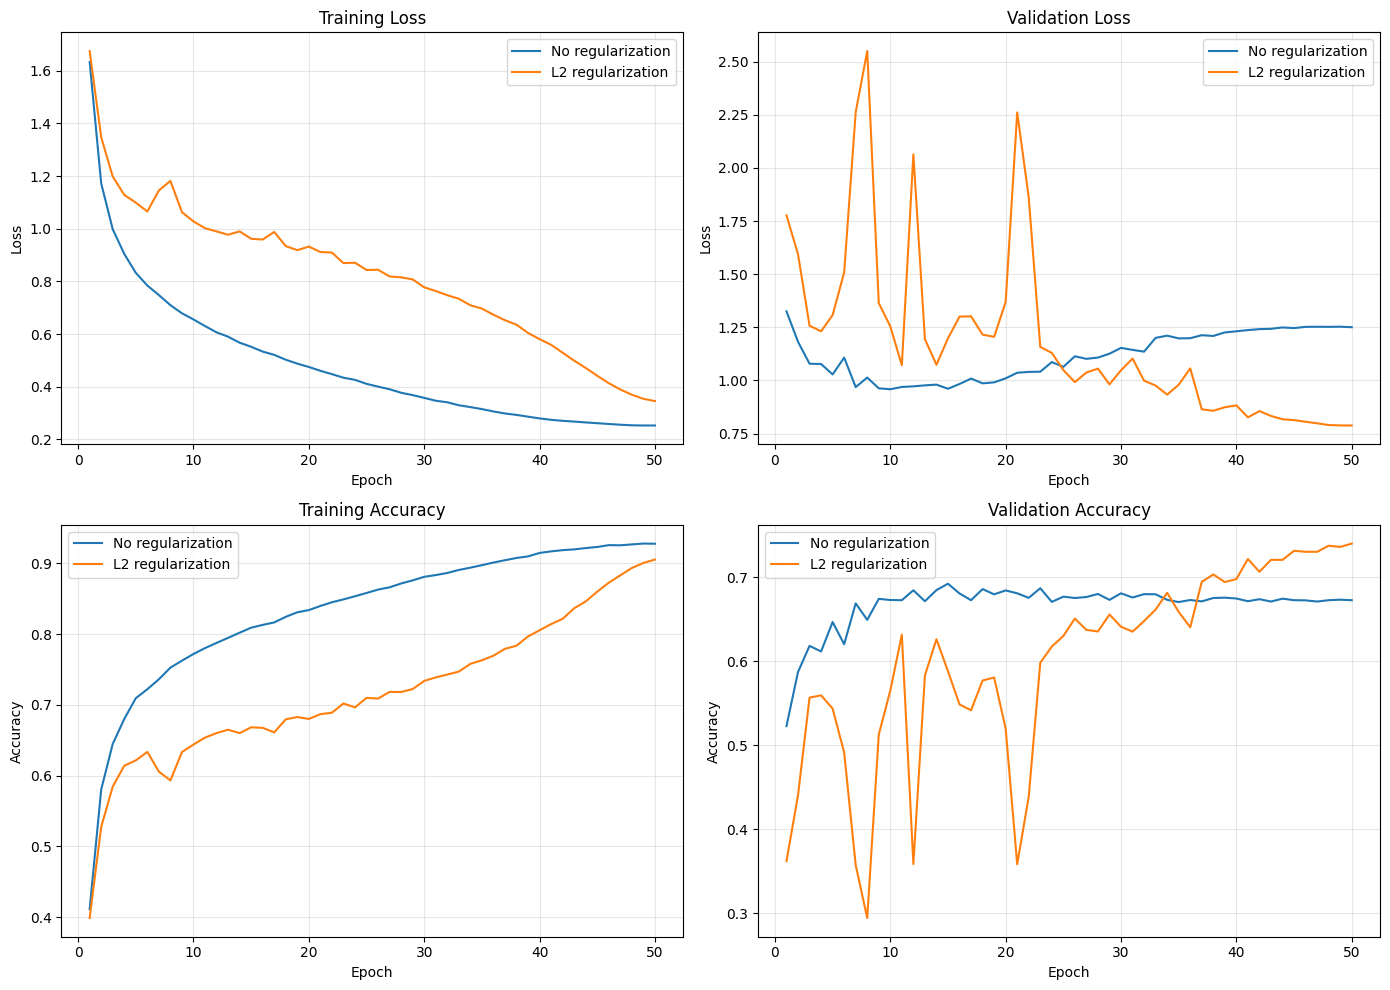


===== Generalization Gap Summary =====
No regularization    | Final Train Acc: 0.9275 | Final Val Acc: 0.6726 | Gap: 0.2549 | Best Val Acc: 0.6922
L2 regularization    | Final Train Acc: 0.9051 | Final Val Acc: 0.7400 | Gap: 0.1651 | Best Val Acc: 0.7400


In [2]:
# ============================================================
# CIFAR-10: Effect of L2 Regularization on an Overparameterized CNN
# Configurable version
# ============================================================

import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# --------------------------
# Reproducibility
# --------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# --------------------------
# Device
# --------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --------------------------
# Hyperparameters
# --------------------------
DATA_ROOT = "./data"
BATCH_SIZE = 1024
EPOCHS = 50
LR = 0.05
MOMENTUM = 0.9
L2_WEIGHT_DECAY = 5e-2
# L2_WEIGHT_DECAY = 5e-3
VAL_RATIO = 0.10
NUM_WORKERS = 2 if torch.cuda.is_available() else 0

# --------------------------
# MODEL CONFIG
# Tweak these freely
# --------------------------
MODEL_CONFIG = {
    "input_channels": 3,
    "num_classes": 10,

    # one entry per block
    "conv_channels": [8, 16, 32],

    # how many conv layers inside each block
    # must match length of conv_channels
    "convs_per_block": [1, 1, 1],

    # FC hidden layers after conv backbone
    "fc_dims": [32, 64],

    # architecture knobs
    "kernel_size": 3,
    "use_batchnorm": True,
    "dropout": 0.0,

    # output size after feature extractor
    # adaptive pooling makes classifier shape stable
    "adaptive_pool_output": 4,
}

# --------------------------
# CIFAR-10 transforms
# --------------------------
mean = (0.4914, 0.4822, 0.4465)
std  = (0.2470, 0.2435, 0.2616)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

# --------------------------
# Dataset + Train/Val split
# --------------------------
full_train_dataset = datasets.CIFAR10(
    root=DATA_ROOT,
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root=DATA_ROOT,
    train=False,
    download=True,
    transform=transform
)

num_train = int((1 - VAL_RATIO) * len(full_train_dataset))
num_val = len(full_train_dataset) - num_train

split_generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(
    full_train_dataset,
    [num_train, num_val],
    generator=split_generator
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

# --------------------------
# Configurable Overparameterized CNN
# --------------------------
class ConfigurableOverParamCNN(nn.Module):
    def __init__(
        self,
        input_channels=3,
        num_classes=10,
        conv_channels=[128, 256, 512],
        convs_per_block=[2, 2, 2],
        fc_dims=[2048, 1024],
        kernel_size=3,
        use_batchnorm=True,
        dropout=0.0,
        adaptive_pool_output=4,
    ):
        super().__init__()

        assert len(conv_channels) == len(convs_per_block), \
            "conv_channels and convs_per_block must have same length"

        padding = kernel_size // 2
        layers = []
        in_ch = input_channels

        # convolutional backbone
        for out_ch, num_convs in zip(conv_channels, convs_per_block):
            for _ in range(num_convs):
                layers.append(nn.Conv2d(in_ch, out_ch, kernel_size=kernel_size, padding=padding))
                if use_batchnorm:
                    layers.append(nn.BatchNorm2d(out_ch))
                layers.append(nn.ReLU(inplace=True))
                in_ch = out_ch

            # one pooling after each block
            layers.append(nn.MaxPool2d(2))

        self.features = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool2d((adaptive_pool_output, adaptive_pool_output))

        # classifier
        classifier_layers = [nn.Flatten()]
        in_features = conv_channels[-1] * adaptive_pool_output * adaptive_pool_output

        for hidden_dim in fc_dims:
            classifier_layers.append(nn.Linear(in_features, hidden_dim))
            if use_batchnorm:
                classifier_layers.append(nn.BatchNorm1d(hidden_dim))
            classifier_layers.append(nn.ReLU(inplace=True))
            if dropout > 0:
                classifier_layers.append(nn.Dropout(dropout))
            in_features = hidden_dim

        classifier_layers.append(nn.Linear(in_features, num_classes))
        self.classifier = nn.Sequential(*classifier_layers)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

# --------------------------
# Utility functions
# --------------------------
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)
            loss = criterion(logits, labels)

            running_loss += loss.item() * labels.size(0)
            running_correct += (logits.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

    avg_loss = running_loss / total
    avg_acc = running_correct / total
    return avg_loss, avg_acc

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        running_correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / total
    avg_acc = running_correct / total
    return avg_loss, avg_acc

def build_optimizer(model, lr, momentum, weight_decay):
    """
    Apply L2 only to Conv/Linear weights.
    Exclude bias and BatchNorm params.
    """
    decay_params = []
    no_decay_params = []

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue

        if param.ndim == 1 or name.endswith(".bias") or "bn" in name.lower():
            no_decay_params.append(param)
        else:
            decay_params.append(param)

    optimizer = torch.optim.SGD(
        [
            {"params": decay_params, "weight_decay": weight_decay},
            {"params": no_decay_params, "weight_decay": 0.0},
        ],
        lr=lr,
        momentum=momentum,
        nesterov=True,
    )
    return optimizer

def run_experiment(name, initial_state_dict, model_config, weight_decay):
    model = ConfigurableOverParamCNN(**model_config).to(device)
    model.load_state_dict(copy.deepcopy(initial_state_dict))

    criterion = nn.CrossEntropyLoss()
    optimizer = build_optimizer(model, LR, MOMENTUM, weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    print(f"\n===== Running: {name} | weight_decay={weight_decay} =====")

    for epoch in range(EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch [{epoch+1:02d}/{EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

    test_loss, test_acc = evaluate(model, test_loader, criterion)
    print(f"Final Test Loss ({name}): {test_loss:.4f}")
    print(f"Final Test Acc  ({name}): {test_acc:.4f}")

    return model, history, (test_loss, test_acc)

def plot_histories(histories):
    epochs = range(1, EPOCHS + 1)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    for label, hist in histories.items():
        axes[0, 0].plot(epochs, hist["train_loss"], label=label)
    axes[0, 0].set_title("Training Loss")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    for label, hist in histories.items():
        axes[0, 1].plot(epochs, hist["val_loss"], label=label)
    axes[0, 1].set_title("Validation Loss")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("Loss")
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    for label, hist in histories.items():
        axes[1, 0].plot(epochs, hist["train_acc"], label=label)
    axes[1, 0].set_title("Training Accuracy")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("Accuracy")
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    for label, hist in histories.items():
        axes[1, 1].plot(epochs, hist["val_acc"], label=label)
    axes[1, 1].set_title("Validation Accuracy")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_ylabel("Accuracy")
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def summarize_gap(histories):
    print("\n===== Generalization Gap Summary =====")
    for label, hist in histories.items():
        final_train_acc = hist["train_acc"][-1]
        final_val_acc = hist["val_acc"][-1]
        gap = final_train_acc - final_val_acc
        best_val = max(hist["val_acc"])
        print(
            f"{label:20s} | "
            f"Final Train Acc: {final_train_acc:.4f} | "
            f"Final Val Acc: {final_val_acc:.4f} | "
            f"Gap: {gap:.4f} | "
            f"Best Val Acc: {best_val:.4f}"
        )

# --------------------------
# Fair setup: same initialization
# --------------------------
base_model = ConfigurableOverParamCNN(**MODEL_CONFIG)
initial_state_dict = copy.deepcopy(base_model.state_dict())

# --------------------------
# Run experiments
# --------------------------
baseline_model, baseline_history, baseline_test = run_experiment(
    name="No regularization",
    initial_state_dict=initial_state_dict,
    model_config=MODEL_CONFIG,
    weight_decay=0.0
)

l2_model, l2_history, l2_test = run_experiment(
    name="L2 regularization",
    initial_state_dict=initial_state_dict,
    model_config=MODEL_CONFIG,
    weight_decay=L2_WEIGHT_DECAY
)

histories = {
    "No regularization": baseline_history,
    "L2 regularization": l2_history,
}

plot_histories(histories)
summarize_gap(histories)

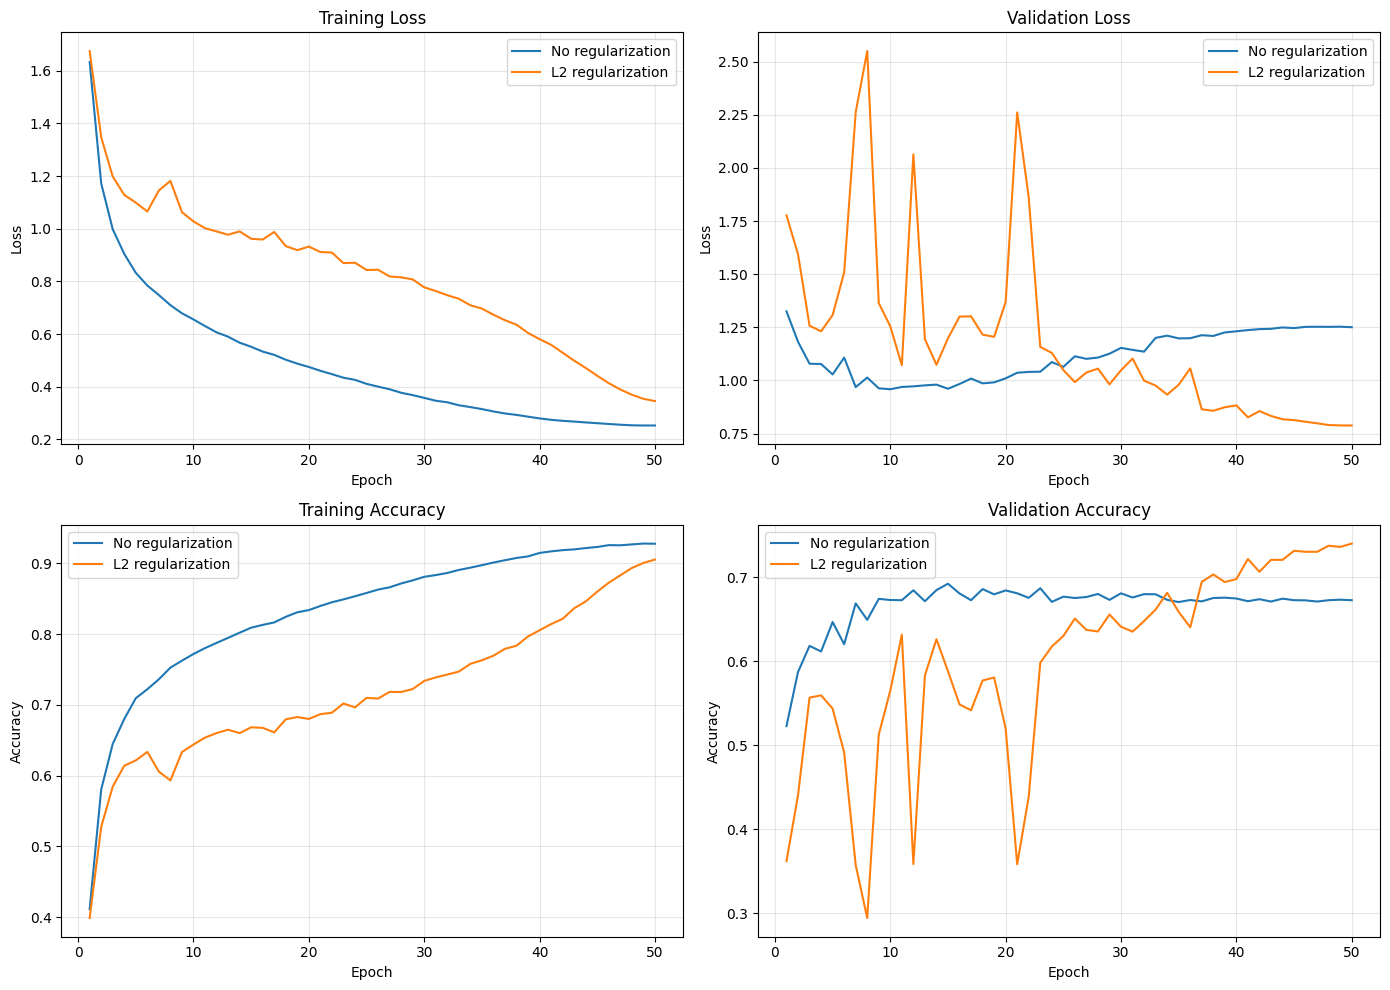


===== Generalization Gap Summary =====
No regularization    | Final Train Acc: 0.9275 | Final Val Acc: 0.6726 | Gap: 0.2549 | Best Val Acc: 0.6922
L2 regularization    | Final Train Acc: 0.9051 | Final Val Acc: 0.7400 | Gap: 0.1651 | Best Val Acc: 0.7400


In [3]:
def plot_histories(histories):
    epochs = range(1, EPOCHS + 1)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    for label, hist in histories.items():
        axes[0, 0].plot(epochs, hist["train_loss"], label=label)
    axes[0, 0].set_title("Training Loss")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    for label, hist in histories.items():
        axes[0, 1].plot(epochs, hist["val_loss"], label=label)
    axes[0, 1].set_title("Validation Loss")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("Loss")
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    for label, hist in histories.items():
        axes[1, 0].plot(epochs, hist["train_acc"], label=label)
    axes[1, 0].set_title("Training Accuracy")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("Accuracy")
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    for label, hist in histories.items():
        axes[1, 1].plot(epochs, hist["val_acc"], label=label)
    axes[1, 1].set_title("Validation Accuracy")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_ylabel("Accuracy")
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("q4_plot_histories.pdf")    
    plt.show()

plot_histories(histories)
summarize_gap(histories)